# Model Training v2 — Improved Multi-class Pipeline

Improvements over v1:
- **MIN_SAMPLES_PER_CLASS**: classes below the threshold are dropped (e.g. Morbus Parkinson with only 14 samples from 1 speaker)
- **Single token per speaker**: uses sustained /a/ at normal pitch (`a_n`) — the standard clinical voice assessment vowel — giving one independent sample per speaker
- **Stratified splitting**: guarantees every class appears in both train and test sets
- **Aggressive dimensionality reduction**: SelectKBest(k=30) instead of SelectFromModel to combat curse of dimensionality
- **MAX_SAMPLES_PER_CLASS disabled**: no cap needed since single-token filtering naturally limits samples

> Note: Splits are now speaker-grouped and stratified by pathology to prevent data leakage.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, StratifiedGroupKFold
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

sys.path.append("..")
from src.features import FeatureOptions, load_feature_tables

In [2]:
# Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Cap per-class samples (applied after token filtering)
MAX_SAMPLES_PER_CLASS = 200

# Drop any pathology class with fewer than this many samples
MIN_SAMPLES_PER_CLASS = 50

# Number of best features to keep (aggressive reduction)
N_SELECT_FEATURES = 50

# Use a single vowel token per speaker instead of all tokens
# "a_n" = sustained /a/ at normal pitch — standard clinical voice assessment token
# Set to None to use all tokens
SELECTED_TOKEN = "a_n"

opts = FeatureOptions(
    prefix=Path(".."),
    include_splits=True,
    random_seed=RANDOM_SEED,
    max_samples_per_class=MAX_SAMPLES_PER_CLASS,
    selected_token=SELECTED_TOKEN,  # token filter applied at manifest level before extraction
)

opts

FeatureOptions(prefix=WindowsPath('..'), input_manifest=WindowsPath('data/processed/manifests/dataset_manifest.csv'), output_core=WindowsPath('data/processed/features/sample_core.csv'), output_acoustic=WindowsPath('data/processed/features/acoustic_features.csv'), output_multifractal=WindowsPath('data/processed/features/multifractal_features.csv'), output_opensmile=WindowsPath('data/processed/features/opensmile_features.csv'), output_splits=WindowsPath('data/processed/features/sample_splits.csv'), output_summary_json=WindowsPath('data/processed/features/feature_summary.json'), include_splits=True, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15, random_seed=42, max_samples_per_class=200, normalize_audio=True, target_sample_rate=None, selected_token='a_n', mfdfa_order=1, mfdfa_q_min=-5.0, mfdfa_q_max=5.0, mfdfa_q_step=1.0, mfdfa_num_scales=20)

In [3]:
tables = load_feature_tables(options=opts, build_if_missing=True, save_if_built=True)

for name, df in tables.items():
    print(f"{name}: {df.shape}")

core_df = tables["core"].copy()
acoustic_df = tables["acoustic"].copy()
multifractal_df = tables["multifractal"].copy()
opensmile_df = tables.get("opensmile", pd.DataFrame()).copy()
splits_df = tables.get("splits", pd.DataFrame())

core: (595, 18)
acoustic: (595, 87)
multifractal: (595, 17)
opensmile: (595, 91)
splits: (595, 3)


In [4]:
# Build one training table
#DEBUG
# df = core_df.merge(acoustic_df, on="sample_key", how="left")
df = core_df.copy() # temp

df = df.merge(multifractal_df, on="sample_key", how="left")
if not opensmile_df.empty:
    df = df.merge(opensmile_df, on="sample_key", how="left")
if not splits_df.empty:
    df = df.merge(splits_df, on="sample_key", how="left")

# Filter to successfully extracted samples
if "feature_status" in df.columns:
    df = df[df["feature_status"].isin(["ok", "partial_failure"])].copy()
if "acoustic_status" in df.columns:
    df = df[df["acoustic_status"] == "ok"].copy()
if "mf_status" in df.columns:
    df = df[df["mf_status"] == "ok"].copy()
if "opensmile_status" in df.columns:
    df = df[df["opensmile_status"] == "ok"].copy()

print(f"Total samples: {df.shape[0]}")
if SELECTED_TOKEN:
    print(f"Token: {SELECTED_TOKEN} (filtered at extraction level)")
df.shape

Total samples: 595
Token: a_n (filtered at extraction level)


(595, 126)

In [5]:
df.head()

,sample_key,duplicate_class_key,recording_id,speaker_id,pathology_de,pathology_en,is_healthy,modality,token,sex,...,os_spectralFluxUV_sma3nz_amean,os_loudnessPeaksPerSec,os_VoicedSegmentsPerSec,os_MeanVoicedSegmentLengthSec,os_StddevVoicedSegmentLengthSec,os_MeanUnvoicedSegmentLength,os_StddevUnvoicedSegmentLength,os_equivalentSoundLevel_dBp,split,split_seed
0,Morbus Parkinson::1580::vowels::a_n,Morbus Parkinson::1580,1580,1887,Morbus Parkinson,parkinson's disease,False,vowels,a_n,m,...,0.0,2.816901,1.538462,0.64,0.0,0.0,0.0,-15.389905,train,42
1,Phonationsknötchen::131::vowels::a_n,Phonationsknötchen::131,131,1317,Phonationsknötchen,Phonationsknötchen,False,vowels,a_n,m,...,0.0,3.535354,0.520833,1.91,0.0,0.0,0.0,-14.512176,val,42
2,Phonationsknötchen::870::vowels::a_n,Phonationsknötchen::870,870,1466,Phonationsknötchen,Phonationsknötchen,False,vowels,a_n,w,...,0.0,3.846154,2.173913,0.45,0.0,0.0,0.0,-8.524747,train,42
3,Phonationsknötchen::900::vowels::a_n,Phonationsknötchen::900,900,1492,Phonationsknötchen,Phonationsknötchen,False,vowels,a_n,m,...,0.0,5.147059,0.769231,1.29,0.0,0.0,0.0,-14.684231,test,42
4,Phonationsknötchen::1044::vowels::a_n,Phonationsknötchen::1044,1044,1540,Phonationsknötchen,Phonationsknötchen,False,vowels,a_n,w,...,0.0,6.034483,0.909091,1.09,0.0,0.0,0.0,-15.348408,train,42


In [6]:
# Diagnose class distribution BEFORE filtering
target_col = "pathology_de" if "pathology_de" in df.columns else "pathology_en"

print("=== Class distribution BEFORE MIN_SAMPLES_PER_CLASS filter ===")
class_counts = df[target_col].value_counts()
display(class_counts.to_frame("count"))

# Filter out classes below minimum threshold
small_classes = class_counts[class_counts < MIN_SAMPLES_PER_CLASS].index.tolist()
if small_classes:
    print(f"\nDropping classes with < {MIN_SAMPLES_PER_CLASS} samples: {small_classes}")
    df = df[~df[target_col].isin(small_classes)].copy()

# Also show per-class speaker/recording counts
diag = df.groupby(target_col).agg(
    samples=("sample_key", "count"),
    recordings=("recording_id", "nunique"),
    speakers=("speaker_id", "nunique"),
    tokens=("token", "nunique"),
).sort_values("samples", ascending=False)

print("\n=== Class distribution AFTER filter ===")
display(diag)

=== Class distribution BEFORE MIN_SAMPLES_PER_CLASS filter ===


,count
pathology_de,
Rekurrensparese,200
healthy,200
Reinke Ödem,68
Spasmodische Dysphonie,64
Stimmlippenpolyp,45
Phonationsknötchen,17
Morbus Parkinson,1



Dropping classes with < 50 samples: ['Stimmlippenpolyp', 'Phonationsknötchen', 'Morbus Parkinson']

=== Class distribution AFTER filter ===


,samples,recordings,speakers,tokens
pathology_de,,,,
Rekurrensparese,200,200,149,1
healthy,200,200,200,1
Reinke Ödem,68,68,54,1
Spasmodische Dysphonie,64,64,12,1


In [7]:
# Select target and features
exclude_cols = {
    "sample_key",
    "duplicate_class_key",
    "recording_id",
    "speaker_id",
    "wav_path",
    "feature_status",
    "feature_error",
    "acoustic_status",
    "acoustic_error",
    "mf_status",
    "mf_error",
    "opensmile_status",
    "opensmile_error",
    "split",
    "split_seed",
    "pathology_de",
    "pathology_en",
}

numeric_feature_cols = [
    c for c in df.columns
    if c not in exclude_cols and pd.api.types.is_numeric_dtype(df[c])
]

categorical_feature_cols = ["sex"] if "sex" in df.columns else []

X = df[numeric_feature_cols + categorical_feature_cols].copy()
y_binary = df["is_healthy"].astype(int).copy()
y_multi = df[target_col].astype(str).copy()
groups = df["speaker_id"].copy()

print(f"Samples: {len(df)}")
print(f"Binary classes: {y_binary.nunique()}")
print(f"Multi classes: {y_multi.nunique()} — {sorted(y_multi.unique())}")
print(f"Numeric features: {len(numeric_feature_cols)}")
print(f"Categorical features: {len(categorical_feature_cols)}")
print(f"Unique speakers: {groups.nunique()}")

Samples: 532
Binary classes: 2
Multi classes: 4 — ['Reinke Ödem', 'Rekurrensparese', 'Spasmodische Dysphonie', 'healthy']
Numeric features: 108
Categorical features: 1
Unique speakers: 408


In [8]:
# Stratified Grouped train/test split — guarantees all classes appear in both sets
# and no speaker overlaps between train and test sets.
# Ignore precomputed splits since they may not cover all classes after filtering
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
train_idx, test_idx = next(sgkf.split(X, y_multi, groups))

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]
y_bin_train = y_binary.iloc[train_idx]
y_bin_test = y_binary.iloc[test_idx]
y_multi_train = y_multi.iloc[train_idx]
y_multi_test = y_multi.iloc[test_idx]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nTrain class distribution:")
print(y_multi_train.value_counts())
print("\nTest class distribution:")
print(y_multi_test.value_counts())

Train shape: (420, 109)
Test shape: (112, 109)

Train class distribution:
pathology_de
Rekurrensparese           160
healthy                   160
Reinke Ödem               55
Spasmodische Dysphonie     45
Name: count, dtype: int64

Test class distribution:
pathology_de
Rekurrensparese           40
healthy                   40
Spasmodische Dysphonie    19
Reinke Ödem              13
Name: count, dtype: int64
 (420, 109)
Test shape: (112, 109)

Train class distribution:
pathology_de
Rekurrensparese           160
healthy                   160
Reinke Ödem               55
Spasmodische Dysphonie     45
Name: count, dtype: int64

Test class distribution:
pathology_de
Rekurrensparese           40
healthy                   40
Spasmodische Dysphonie    19
Reinke Ödem              13
Name: count, dtype: int64


In [9]:
# Shared preprocessing for numeric feature space
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("variance", VarianceThreshold(threshold=0.0)),
])

# Preprocessing for categorical feature space
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_feature_cols),
        ("cat", categorical_transformer, categorical_feature_cols)
    ],
    remainder="drop",
)

print(f"Feature selection: SelectKBest(k={N_SELECT_FEATURES}) with ANOVA F-test")

Feature selection: SelectKBest(k=50) with ANOVA F-test


In [10]:
models = {
    "LogReg": LogisticRegression(max_iter=5000, class_weight="balanced", random_state=RANDOM_SEED),
    "RandomForest": RandomForestClassifier(
        n_estimators=400,
        random_state=RANDOM_SEED,
        class_weight="balanced_subsample",
        n_jobs=-1,
    ),
    "SVM-RBF": SVC(kernel="rbf", C=3.0, gamma="scale", class_weight="balanced"),
    "XGBoost": XGBClassifier(random_state=RANDOM_SEED, n_jobs=-1, eval_metric="logloss"),
    "LightGBM": LGBMClassifier(random_state=RANDOM_SEED, n_jobs=-1, class_weight="balanced", verbose=-1),
}

results_bin = []
trained_pipelines_bin = {}

print("--- Binary Classification (Healthy vs Pathological) ---")
for name, model in models.items():
    pipe = Pipeline(steps=[
        ("prep", preprocessor),
        ("selector", SelectKBest(f_classif, k=N_SELECT_FEATURES)),
        ("model", model),
    ])

    pipe.fit(X_train, y_bin_train)
    y_pred = pipe.predict(X_test)

    acc = accuracy_score(y_bin_test, y_pred)
    bacc = balanced_accuracy_score(y_bin_test, y_pred)
    f1m = f1_score(y_bin_test, y_pred, average="macro", zero_division=0)

    results_bin.append({
        "model": name,
        "accuracy": acc,
        "balanced_accuracy": bacc,
        "f1_macro": f1m,
    })

    trained_pipelines_bin[name] = (pipe, y_pred)

results_bin_df = pd.DataFrame(results_bin).sort_values(by="f1_macro", ascending=False)
display(results_bin_df)

--- Binary Classification (Healthy vs Pathological) ---


g:\Projects\multifractal-speech-analysis\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,model,accuracy,balanced_accuracy,f1_macro
0,LogReg,1.000000,1.0000,1.000000
1,RandomForest,1.000000,1.0000,1.000000
3,XGBoost,1.000000,1.0000,1.000000
4,LightGBM,1.000000,1.0000,1.000000
2,SVM-RBF,0.991071,0.9875,0.990223


In [11]:
# Multi-class classification on pathological samples only
pathological_train_mask = y_bin_train == 0
pathological_test_mask = y_bin_test == 0

X_train_patho = X_train[pathological_train_mask]
y_multi_train_patho = y_multi_train[pathological_train_mask]

X_test_patho = X_test[pathological_test_mask]
y_multi_test_patho = y_multi_test[pathological_test_mask]

print(f"Pathological train: {len(X_train_patho)}, test: {len(X_test_patho)}")
print(f"Train classes: {sorted(y_multi_train_patho.unique())}")
print(f"Test classes:  {sorted(y_multi_test_patho.unique())}")

# Encode labels for XGBoost/LightGBM
le = LabelEncoder()
y_multi_train_patho_enc = le.fit_transform(y_multi_train_patho)
y_multi_test_patho_enc = le.transform(y_multi_test_patho)

results_multi = []
trained_pipelines_multi = {}

print("\n--- Multi-class Classification (Specific Pathology) ---")
for name, model in models.items():
    pipe = Pipeline(steps=[
        ("prep", preprocessor),
        ("selector", SelectKBest(f_classif, k=N_SELECT_FEATURES)),
        ("model", model),
    ])

    pipe.fit(X_train_patho, y_multi_train_patho_enc)
    y_pred_enc = pipe.predict(X_test_patho)
    y_pred = le.inverse_transform(y_pred_enc)

    acc = accuracy_score(y_multi_test_patho, y_pred)
    bacc = balanced_accuracy_score(y_multi_test_patho, y_pred)
    f1m = f1_score(y_multi_test_patho, y_pred, average="macro", zero_division=0)

    results_multi.append({
        "model": name,
        "accuracy": acc,
        "balanced_accuracy": bacc,
        "f1_macro": f1m,
    })

    trained_pipelines_multi[name] = (pipe, y_pred)

results_multi_df = pd.DataFrame(results_multi).sort_values(by="f1_macro", ascending=False)
display(results_multi_df)

Pathological train: 260, test: 72
Train classes: ['Reinke Ödem', 'Rekurrensparese', 'Spasmodische Dysphonie']
Test classes:  ['Reinke Ödem', 'Rekurrensparese', 'Spasmodische Dysphonie']

--- Multi-class Classification (Specific Pathology) ---


g:\Projects\multifractal-speech-analysis\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,model,accuracy,balanced_accuracy,f1_macro
2,SVM-RBF,0.569444,0.523954,0.453654
4,LightGBM,0.541667,0.480769,0.415771
3,XGBoost,0.541667,0.446154,0.408889
1,RandomForest,0.569444,0.410897,0.391783
0,LogReg,0.402778,0.423954,0.352556


In [12]:
# Inspect which features were selected by SelectKBest
sample_pipe = trained_pipelines_bin["LogReg"][0]
selector = sample_pipe.named_steps["selector"]
selected_mask = selector.get_support()
n_features = len(selected_mask)

prep = sample_pipe.named_steps["prep"]

# Robustly reconstruct feature names — try multiple approaches
all_feature_names = None

# Method 1: ColumnTransformer.get_feature_names_out() (only if count matches)
try:
    names = prep.get_feature_names_out()
    if len(names) == n_features:
        all_feature_names = names
except (AttributeError, ValueError):
    pass

# Method 2: Reconstruct from sub-transformers
if all_feature_names is None:
    try:
        var_mask = prep.named_transformers_["num"].named_steps["variance"].get_support()
        num_names = np.array(numeric_feature_cols)[var_mask]
        cat_names = prep.named_transformers_["cat"].named_steps["onehot"].get_feature_names_out(categorical_feature_cols)
        names = np.concatenate([num_names, cat_names])
        if len(names) == n_features:
            all_feature_names = names
    except Exception:
        pass

# Method 3: Generic indices
if all_feature_names is None:
    print(f"NOTE: Could not reconstruct {n_features} feature names, using indices")
    all_feature_names = np.array([f"feature_{i}" for i in range(n_features)])

selected_features = all_feature_names[selected_mask]
selected_features = [str(f).replace("num__", "").replace("cat__", "") for f in selected_features]

print(f"Features after preprocessing: {n_features}")
print(f"Selected features (k={N_SELECT_FEATURES}): {len(selected_features)}")
print(f"\nSelected: {selected_features}")

NOTE: Could not reconstruct 107 feature names, using indices
Features after preprocessing: 107
Selected features (k=50): 50

Selected: ['feature_0', 'feature_2', 'feature_5', 'feature_7', 'feature_10', 'feature_11', 'feature_14', 'feature_18', 'feature_22', 'feature_23', 'feature_24', 'feature_26', 'feature_27', 'feature_29', 'feature_30', 'feature_31', 'feature_33', 'feature_34', 'feature_35', 'feature_36', 'feature_37', 'feature_39', 'feature_41', 'feature_45', 'feature_47', 'feature_48', 'feature_49', 'feature_51', 'feature_53', 'feature_58', 'feature_60', 'feature_61', 'feature_64', 'feature_66', 'feature_67', 'feature_69', 'feature_70', 'feature_72', 'feature_73', 'feature_74', 'feature_78', 'feature_79', 'feature_81', 'feature_83', 'feature_85', 'feature_87', 'feature_91', 'feature_98', 'feature_99', 'feature_104']


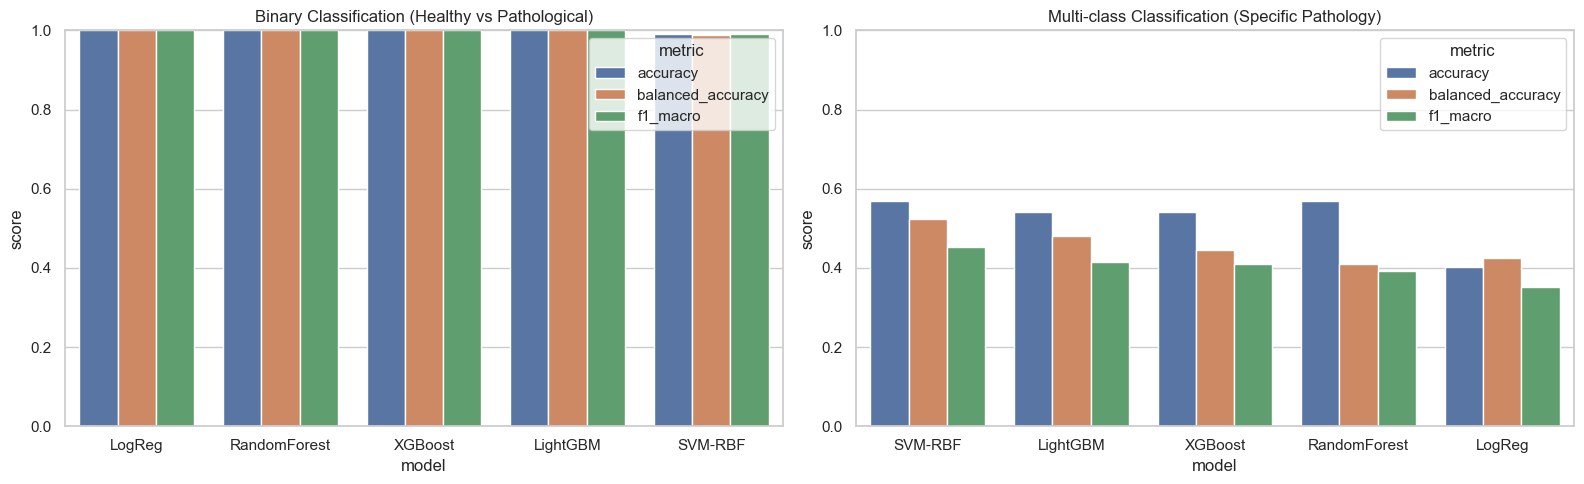

In [13]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

plot_df_bin = results_bin_df.melt(id_vars="model", var_name="metric", value_name="score")
sns.barplot(data=plot_df_bin, x="model", y="score", hue="metric", ax=axes[0])
axes[0].set_ylim(0, 1)
axes[0].set_title("Binary Classification (Healthy vs Pathological)")

plot_df_multi = results_multi_df.melt(id_vars="model", var_name="metric", value_name="score")
sns.barplot(data=plot_df_multi, x="model", y="score", hue="metric", ax=axes[1])
axes[1].set_ylim(0, 1)
axes[1].set_title("Multi-class Classification (Specific Pathology)")

plt.tight_layout()
plt.show()

In [14]:
best_model_name_bin = results_bin_df.iloc[0]["model"]
best_pipe_bin, best_pred_bin = trained_pipelines_bin[best_model_name_bin]

print(f"Best Binary Model: {best_model_name_bin}")
print(classification_report(y_bin_test, best_pred_bin, zero_division=0))

best_model_name_multi = results_multi_df.iloc[0]["model"]
best_pipe_multi, best_pred_multi = trained_pipelines_multi[best_model_name_multi]

print(f"\nBest Multi-class Model: {best_model_name_multi}")
print(classification_report(y_multi_test_patho, best_pred_multi, zero_division=0))

Best Binary Model: LogReg
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        72
           1       1.00      1.00      1.00        40

    accuracy                           1.00       112
   macro avg       1.00      1.00      1.00       112
weighted avg       1.00      1.00      1.00       112


Best Multi-class Model: SVM-RBF
                        precision    recall  f1-score   support

          Reinke Ödem       0.48      0.77      0.59        13
       Rekurrensparese       0.62      0.75      0.68        40
Spasmodische Dysphonie       0.33      0.05      0.09        19

              accuracy                           0.57        72
             macro avg       0.48      0.52      0.45        72
          weighted avg       0.52      0.57      0.51        72



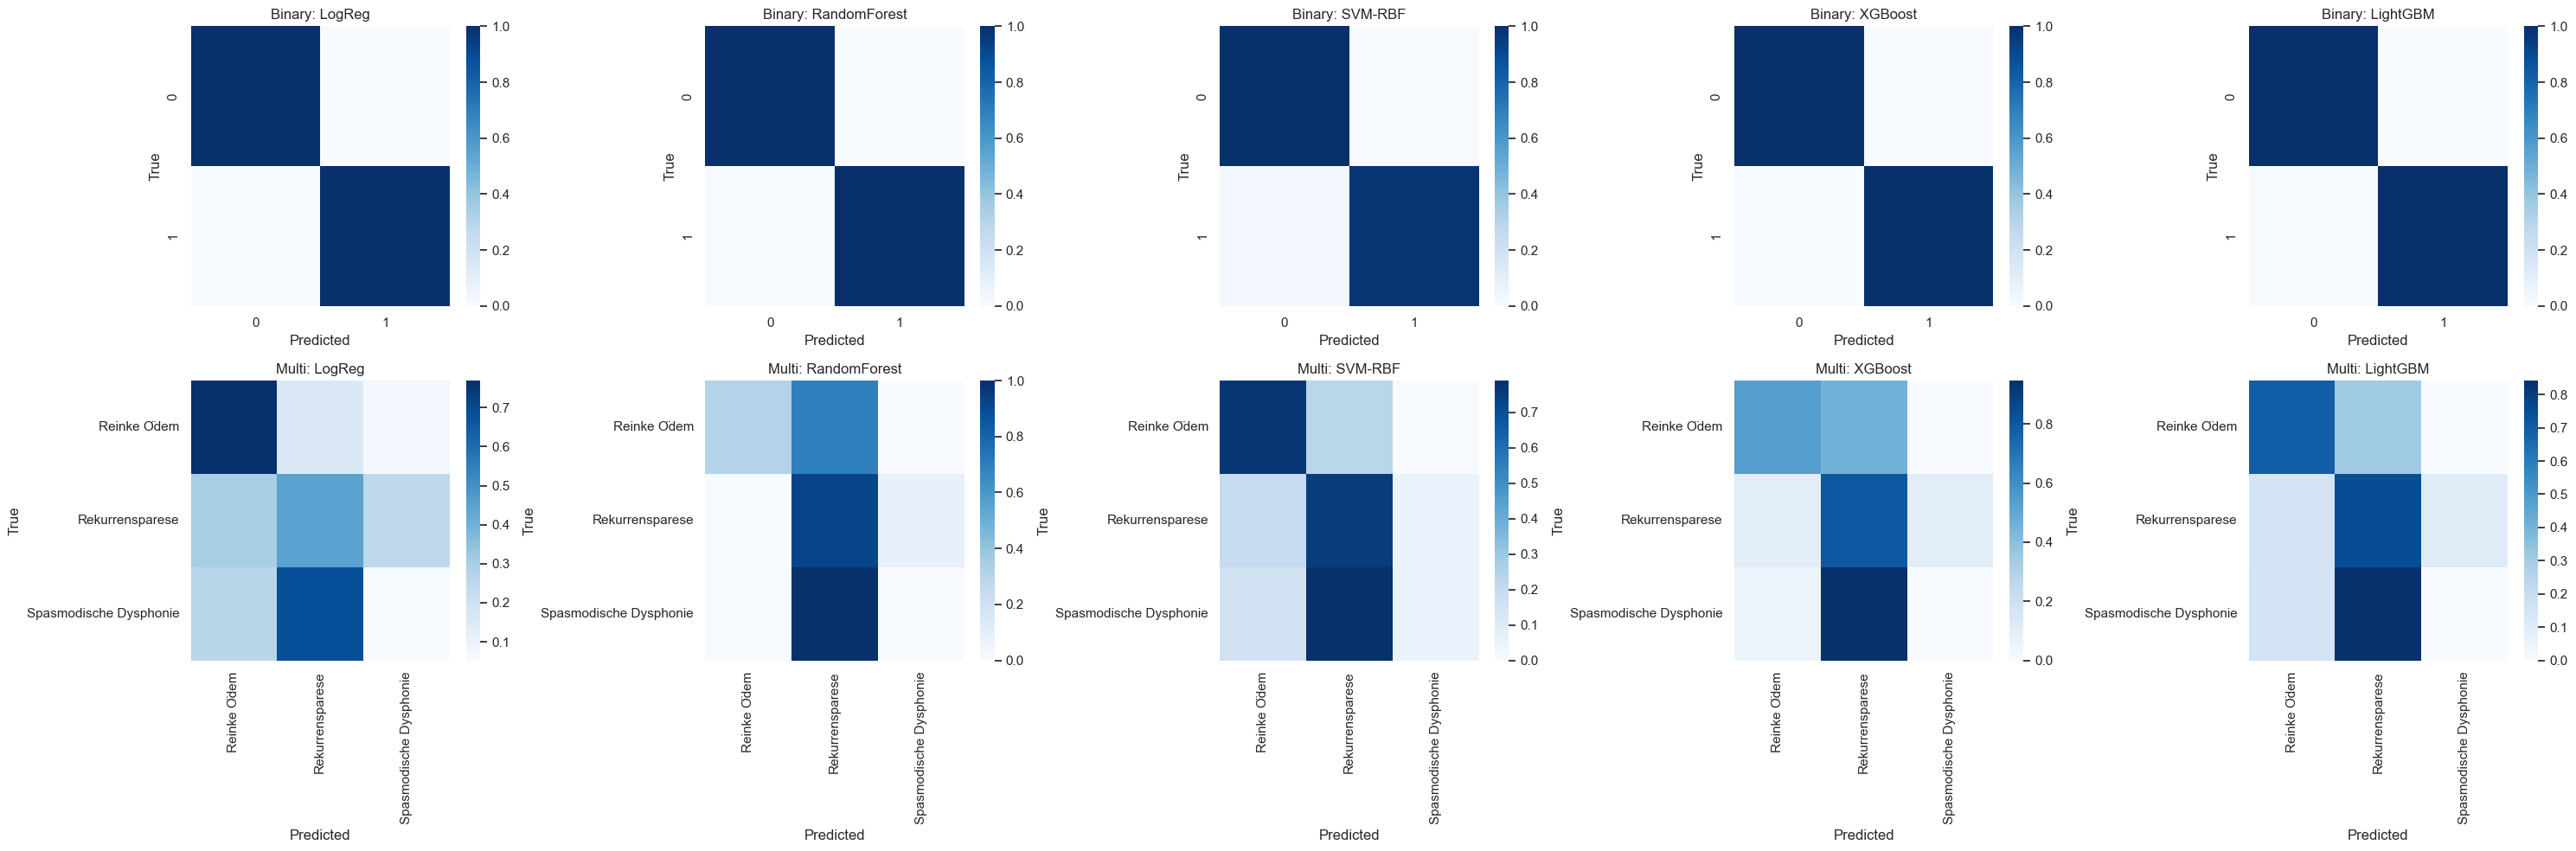

In [15]:
labels_bin = sorted(y_bin_test.unique())
labels_multi = sorted(y_multi_test_patho.unique())

n_models = len(trained_pipelines_bin)
fig, axes = plt.subplots(2, n_models, figsize=(6 * n_models, 10), squeeze=False)

for i, (name, (_, pred)) in enumerate(trained_pipelines_bin.items()):
    cm = confusion_matrix(y_bin_test, pred, labels=labels_bin)
    cm_norm = cm.astype(float) / np.clip(cm.sum(axis=1, keepdims=True), 1, None)

    sns.heatmap(
        cm_norm,
        annot=False,
        cmap="Blues",
        xticklabels=labels_bin,
        yticklabels=labels_bin,
        ax=axes[0, i],
    )
    axes[0, i].set_title(f"Binary: {name}")
    axes[0, i].set_xlabel("Predicted")
    axes[0, i].set_ylabel("True")

for i, (name, (_, pred)) in enumerate(trained_pipelines_multi.items()):
    cm = confusion_matrix(y_multi_test_patho, pred, labels=labels_multi)
    cm_norm = cm.astype(float) / np.clip(cm.sum(axis=1, keepdims=True), 1, None)

    sns.heatmap(
        cm_norm,
        annot=False,
        cmap="Blues",
        xticklabels=labels_multi,
        yticklabels=labels_multi,
        ax=axes[1, i],
    )
    axes[1, i].set_title(f"Multi: {name}")
    axes[1, i].set_xlabel("Predicted")
    axes[1, i].set_ylabel("True")

plt.tight_layout()
plt.show()

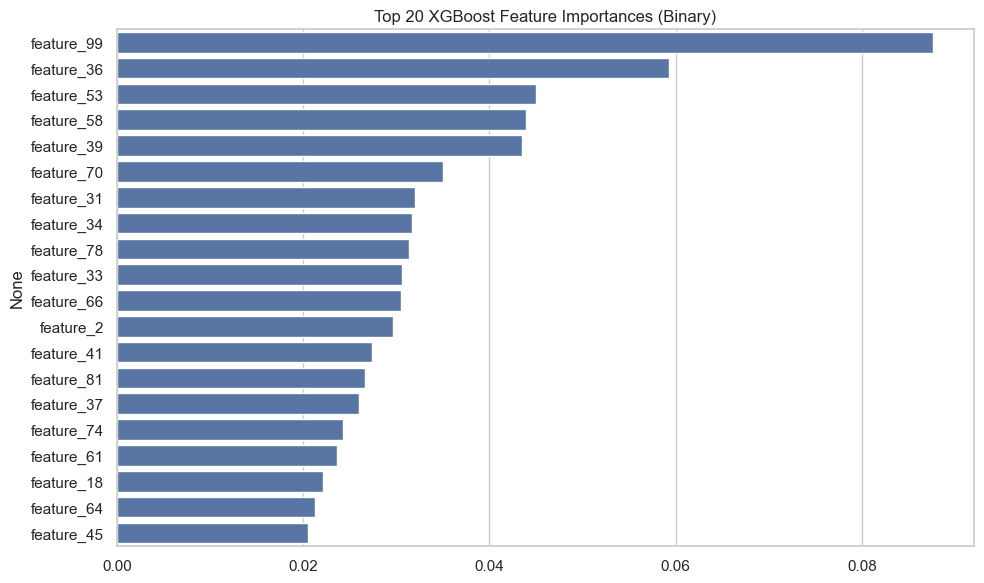

,importance
feature_99,0.087658
feature_36,0.059236
feature_53,0.044988
feature_58,0.043976
feature_39,0.043447
feature_70,0.035001
feature_31,0.031976
feature_34,0.031660
feature_78,0.031353
feature_33,0.030648


In [16]:
# Inspect top feature importances for the best binary model (XGBoost)
if "XGBoost" in trained_pipelines_bin:
    xgb_pipe, _ = trained_pipelines_bin["XGBoost"]
    xgb_model = xgb_pipe.named_steps["model"]
    selector = xgb_pipe.named_steps["selector"]
    preprocessor_step = xgb_pipe.named_steps["prep"]

    sel_mask = selector.get_support()
    n_features = len(sel_mask)
    
    # Robustly reconstruct feature names (same logic as above)
    features_after_prep = None
    
    try:
        names = preprocessor_step.get_feature_names_out()
        if len(names) == n_features:
            features_after_prep = names
    except (AttributeError, ValueError):
        pass

    if features_after_prep is None:
        try:
            var_mask = preprocessor_step.named_transformers_["num"].named_steps["variance"].get_support()
            num_names = np.array(numeric_feature_cols)[var_mask]
            cat_names = preprocessor_step.named_transformers_["cat"].named_steps["onehot"].get_feature_names_out(categorical_feature_cols)
            names = np.concatenate([num_names, cat_names])
            if len(names) == n_features:
                features_after_prep = names
        except Exception:
            pass

    if features_after_prep is None:
        features_after_prep = np.array([f"feature_{i}" for i in range(n_features)])

    final_features = features_after_prep[sel_mask]

    importances = pd.Series(xgb_model.feature_importances_, index=final_features)
    importances.index = importances.index.str.replace(r'^(num__|cat__)', '', regex=True)

    top_imp = importances.sort_values(ascending=False).head(20)

    plt.figure(figsize=(10, 6))
    sns.barplot(x=top_imp.values, y=top_imp.index)
    plt.title(f"Top {len(top_imp)} XGBoost Feature Importances (Binary)")
    plt.tight_layout()
    plt.show()

    display(top_imp.to_frame("importance"))

In [17]:
# Hyperparameter Tuning for XGBoost (Binary Classification)
print("--- Hyperparameter Tuning (Binary Classification) ---")

param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [3, 5, 7],
    "model__learning_rate": [0.01, 0.1, 0.2],
}

xgb_pipe = Pipeline(steps=[
    ("prep", preprocessor),
    ("selector", SelectKBest(f_classif, k=N_SELECT_FEATURES)),
    ("model", XGBClassifier(random_state=RANDOM_SEED, n_jobs=-1, eval_metric="logloss")),
])

grid_search = GridSearchCV(
    xgb_pipe, param_grid, cv=3, scoring="f1_macro", n_jobs=-1, verbose=1
)

grid_search.fit(X_train, y_bin_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV F1 Macro: {grid_search.best_score_:.4f}")

best_tuned_model = grid_search.best_estimator_
y_pred_tuned = best_tuned_model.predict(X_test)

print("\nTuned Model Test Performance:")
print(classification_report(y_bin_test, y_pred_tuned, zero_division=0))

--- Hyperparameter Tuning (Binary Classification) ---
Fitting 3 folds for each of 27 candidates, totalling 81 fits
Best parameters: {'model__learning_rate': 0.01, 'model__max_depth': 3, 'model__n_estimators': 100}
Best CV F1 Macro: 1.0000

Tuned Model Test Performance:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        72
           1       1.00      1.00      1.00        40

    accuracy                           1.00       112
   macro avg       1.00      1.00      1.00       112
weighted avg       1.00      1.00      1.00       112



In [18]:
# Hyperparameter Tuning for XGBoost (Multi-class Classification)
print("--- Hyperparameter Tuning (Multi-class Classification) ---")

param_grid_multi = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [3, 5, 7],
    "model__learning_rate": [0.01, 0.1, 0.2],
}

xgb_pipe_multi = Pipeline(steps=[
    ("prep", preprocessor),
    ("selector", SelectKBest(f_classif, k=N_SELECT_FEATURES)),
    ("model", XGBClassifier(random_state=RANDOM_SEED, n_jobs=-1, eval_metric="mlogloss")),
])

grid_search_multi = GridSearchCV(
    xgb_pipe_multi, param_grid_multi, cv=3, scoring="f1_macro", n_jobs=-1, verbose=1
)

grid_search_multi.fit(X_train_patho, y_multi_train_patho_enc)

print(f"Best parameters: {grid_search_multi.best_params_}")
print(f"Best CV F1 Macro: {grid_search_multi.best_score_:.4f}")

best_tuned_model_multi = grid_search_multi.best_estimator_
y_pred_tuned_enc = best_tuned_model_multi.predict(X_test_patho)
y_pred_tuned_multi = le.inverse_transform(y_pred_tuned_enc)

print("\nTuned Model Test Performance (Multi-class):")
print(classification_report(y_multi_test_patho, y_pred_tuned_multi, zero_division=0))

--- Hyperparameter Tuning (Multi-class Classification) ---
Fitting 3 folds for each of 27 candidates, totalling 81 fits
Best parameters: {'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 200}
Best CV F1 Macro: 0.5433

Tuned Model Test Performance (Multi-class):
                        precision    recall  f1-score   support

          Reinke Ödem       0.50      0.38      0.43        13
       Rekurrensparese       0.55      0.80      0.65        40
Spasmodische Dysphonie       0.00      0.00      0.00        19

              accuracy                           0.51        72
             macro avg       0.35      0.39      0.36        72
          weighted avg       0.40      0.51      0.44        72



## Changes in v2 vs v1

1. **MIN_SAMPLES_PER_CLASS=50** — Morbus Parkinson (14 samples, 1 speaker) is now dropped
2. **StratifiedGroupKFold split** — all remaining classes guaranteed in both train and test, with no speaker leakage across splits.
3. **SelectKBest(k=30)** — aggressive dimensionality reduction from 192 → 30 features
4. Diagnostic cells show class distribution before/after filtering

## Next steps if accuracy is still low
- Aggregate features per speaker (mean across tokens) and classify at speaker level
- Try coarser groupings (structural vs neurological vs functional)